# Part I — Common Foundation
## Time Series Analysis: From Raw Data to a Model-Ready Series

**Purpose of this notebook**  
Before any forecasting model can work — AR(p), dynamic regression, bridge equations, or random forest — you must answer six questions about your data. This notebook walks through each one, always showing both the *mathematical idea* and *what it looks like in real data*.

**Datasets used**
- 📈 **DAX daily prices 1991–1998** — European stock market (EuStockMarkets)
- 🌍 **US quarterly macro data 1959–2009** — GDP, CPI, investment (`statsmodels.macrodata`)
- 🌿 **Monthly CO₂ at Mauna Loa** — a textbook case for trend + seasonality

> **Note on `yfinance` / FRED**: in this offline environment, equivalent public datasets are used. In your own setup, replace the data-loading cells with `yfinance.download()` or `fredapi.Fred().get_series()` — all analysis code is identical.


## Setup — Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.linear_model import OLS
import requests, io, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})
BLUE, RED, GREEN, ORANGE = '#2166ac', '#d6604d', '#4dac26', '#f4a582'
print("Imports OK v")

Imports OK v


In [2]:
# ── US Quarterly Macro (equivalent to FRED: GDPC1, CPIAUCSL, REALINV) ────────
macro_raw = sm.datasets.macrodata.load_pandas().data
macro_raw['period'] = macro_raw.apply(
    lambda r: pd.Period(year=int(r.year), quarter=int(r.quarter), freq='Q'), axis=1)
macro = macro_raw.set_index('period')
print("US Macro:", macro.shape)
macro[['realgdp','realinv','cpi','unemp']].tail(3)

US Macro: (203, 14)


,realgdp,realinv,cpi,unemp
period,,,,
2009Q1,12925.410,1558.494,212.671,8.1
2009Q2,12901.504,1456.678,214.469,9.2
2009Q3,12990.341,1486.398,216.385,9.6


In [4]:
# ── DAX Daily Prices (equivalent to yfinance.download('^GDAXI')) ─────────────
r = requests.get(
    'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets'
    '/master/csv/datasets/EuStockMarkets.csv', timeout=10)
eu = pd.read_csv(io.StringIO(r.text))
eu.index = pd.bdate_range(start='1991-01-02', periods=len(eu))
dax = eu[['DAX']].rename(columns={'DAX': 'price'})
print("DAX:", dax.shape, "| Period:", dax.index[0].date(), "to", dax.index[-1].date())
dax.head(3)

DAX: (1860, 1) | Period: 1991-01-02 to 1998-02-17


,price
1991-01-02,1628.75
1991-01-03,1613.63
1991-01-04,1606.51


In [5]:
# ── CO2 Monthly — Mauna Loa (trend + strong seasonality) ─────────────────────
co2_raw = sm.datasets.co2.load_pandas().data
co2_raw.index = pd.to_datetime(co2_raw.index)
co2 = co2_raw.resample('ME').mean().dropna()
co2.columns = ['co2_ppm']
print("CO2:", co2.shape, "| Period:", co2.index[0].date(), "to", co2.index[-1].date())
co2.head(3)

CO2: (521, 1) | Period: 1958-03-31 to 2001-12-31


,co2_ppm
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333


---
## Topic 1 — Time Series Components & Data Preparation

### The big idea

Every time series is a mixture of up to four underlying signals:

$$y_t = d_t + c_t + s_t + \varepsilon_t$$

| Symbol | Name | What it captures |
|--------|------|-----------------|
| $d_t$ | **Trend** | Long-run direction (GDP growing over decades) |
| $c_t$ | **Cycle** | Medium-run fluctuations, 3–10 years (business cycle) |
| $s_t$ | **Seasonal** | Regular within-year patterns (CO₂ higher in winter) |
| $\varepsilon_t$ | **Irregular** | Random, unpredictable shocks |

Before fitting any model you must decide which components are present and handle them. A model fitted to a series with a strong seasonal component will absorb that pattern into its autoregressive coefficients — corrupting the estimates.

### The seminar's practical rule

> *"Use growth rates for real variables."*

**Why?** GDP in *levels* has a strong upward trend — it grows every year. Linear models assume the relationship between today and yesterday is constant throughout history. A trending series violates that. The fix: **log-differences**, which give approximate percentage growth rates:

$$\Delta \log x_t = \log x_t - \log x_{t-1} \approx \frac{x_t - x_{t-1}}{x_{t-1}} \quad \times 100 = \text{\% growth}$$


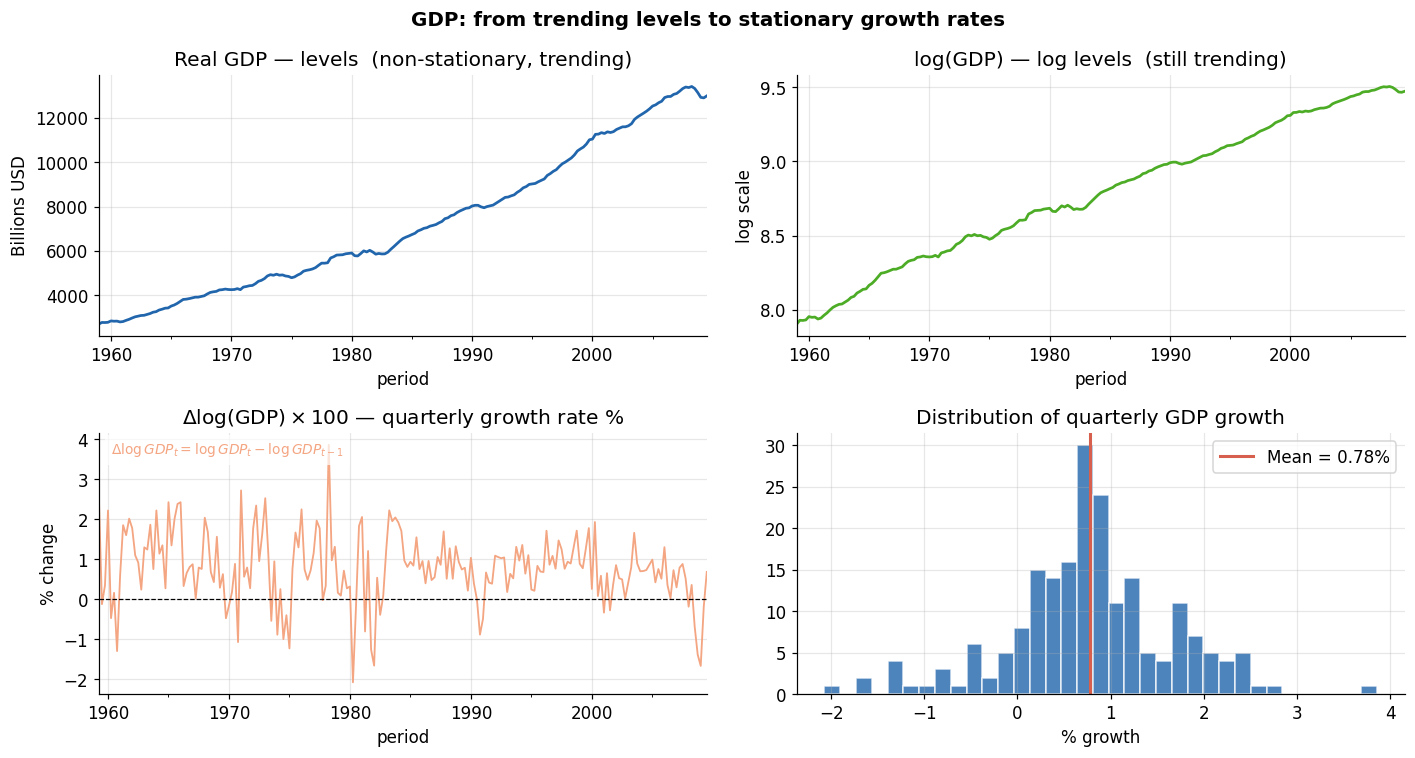

In [6]:
# ── GDP: levels → log-levels → growth rates ─────────────────────────────────

macro['log_gdp']    = np.log(macro['realgdp'])
macro['gdp_growth'] = macro['log_gdp'].diff() * 100     # Delta log * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("GDP: from trending levels to stationary growth rates", fontsize=13, fontweight='bold')

macro['realgdp'].plot(ax=axes[0,0], color=BLUE, lw=1.8)
axes[0,0].set_title("Real GDP — levels  (non-stationary, trending)")
axes[0,0].set_ylabel("Billions USD")

macro['log_gdp'].plot(ax=axes[0,1], color=GREEN, lw=1.8)
axes[0,1].set_title("log(GDP) — log levels  (still trending)")
axes[0,1].set_ylabel("log scale")

macro['gdp_growth'].dropna().plot(ax=axes[1,0], color=ORANGE, lw=1.2)
axes[1,0].axhline(0, color='black', lw=0.8, ls='--')
axes[1,0].set_title(r"$\Delta \log(\mathrm{GDP}) \times 100$ — quarterly growth rate %")
axes[1,0].set_ylabel("% change")
axes[1,0].annotate(r"$\Delta \log GDP_t = \log GDP_t - \log GDP_{t-1}$",
                   xy=(0.02, 0.92), xycoords='axes fraction',
                   fontsize=9, color=ORANGE, bbox=dict(fc='white', alpha=0.7, ec='none'))

macro['gdp_growth'].dropna().hist(ax=axes[1,1], bins=35, color=BLUE, edgecolor='white', alpha=0.8)
axes[1,1].axvline(macro['gdp_growth'].mean(), color=RED, lw=2,
                  label=f"Mean = {macro['gdp_growth'].mean():.2f}%")
axes[1,1].set_title("Distribution of quarterly GDP growth")
axes[1,1].set_xlabel("% growth")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Seasonal adjustment

When your data has a seasonal component, you have two options:
1. **Decompose and remove** the seasonal component, then model the adjusted series
2. **Include seasonal dummies** in your model (regression of $y_t$ on a set of monthly/quarterly dummies)

The dummy approach is the simplest:

$$y_t = \sum_{m=1}^{M} \beta_m D_{m}(t) + \varepsilon_t$$

where $D_m(t) = 1$ if observation $t$ belongs to period $m$ (month, quarter), else 0.  
The **seasonally adjusted series** is then: $y_t^{SA} = y_t - \sum_m \hat{\beta}_m D_m(t) + \bar{y}$


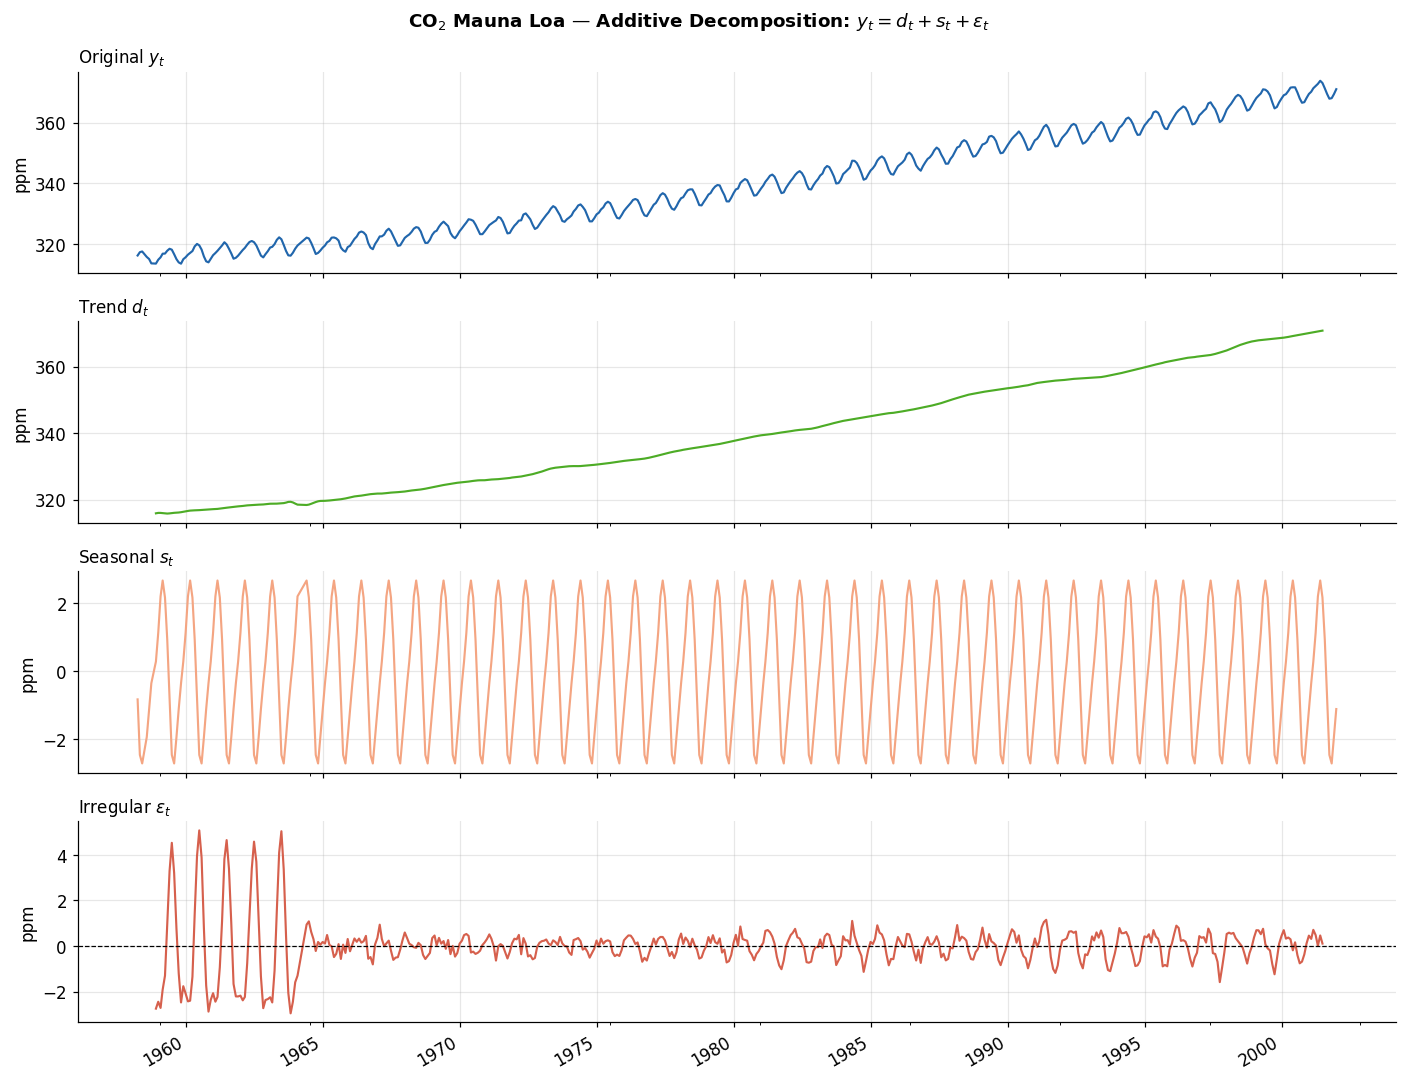

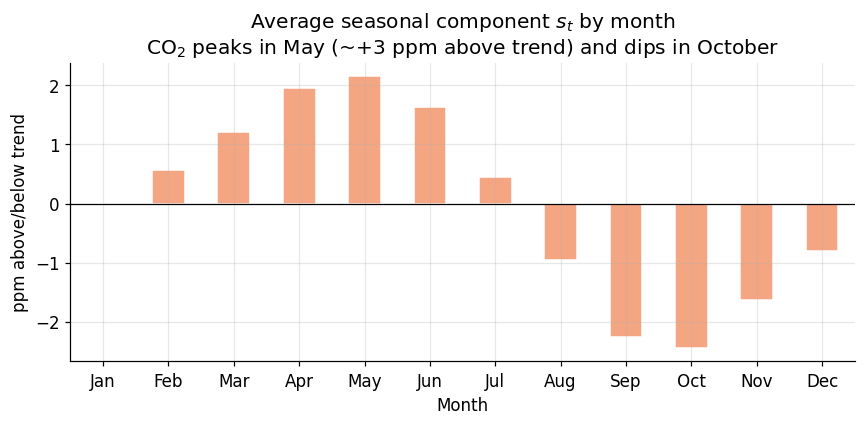

In [7]:
# ── Seasonal decomposition on CO2 ────────────────────────────────────────────
decomp = seasonal_decompose(co2['co2_ppm'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle(r"CO$_2$ Mauna Loa — Additive Decomposition: $y_t = d_t + s_t + \varepsilon_t$",
             fontsize=12, fontweight='bold')

for ax, series, title, color in zip(axes,
        [co2['co2_ppm'], decomp.trend, decomp.seasonal, decomp.resid],
        [r'Original $y_t$', r'Trend $d_t$',
         r'Seasonal $s_t$', r'Irregular $\varepsilon_t$'],
        [BLUE, GREEN, ORANGE, RED]):
    series.plot(ax=ax, color=color, lw=1.4)
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_ylabel("ppm")
    if 'Irregular' in title:
        ax.axhline(0, color='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

# Average seasonal pattern by month
s_by_month = pd.DataFrame({
    'month': pd.to_datetime(decomp.seasonal.dropna().index).month,
    'seasonal': decomp.seasonal.dropna().values
}).groupby('month')['seasonal'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
s_by_month.plot(kind='bar', ax=ax, color=ORANGE, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(r"Average seasonal component $s_t$ by month" "\n"
             r"CO$_2$ peaks in May (~+3 ppm above trend) and dips in October")
ax.set_xlabel("Month")
ax.set_ylabel("ppm above/below trend")
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

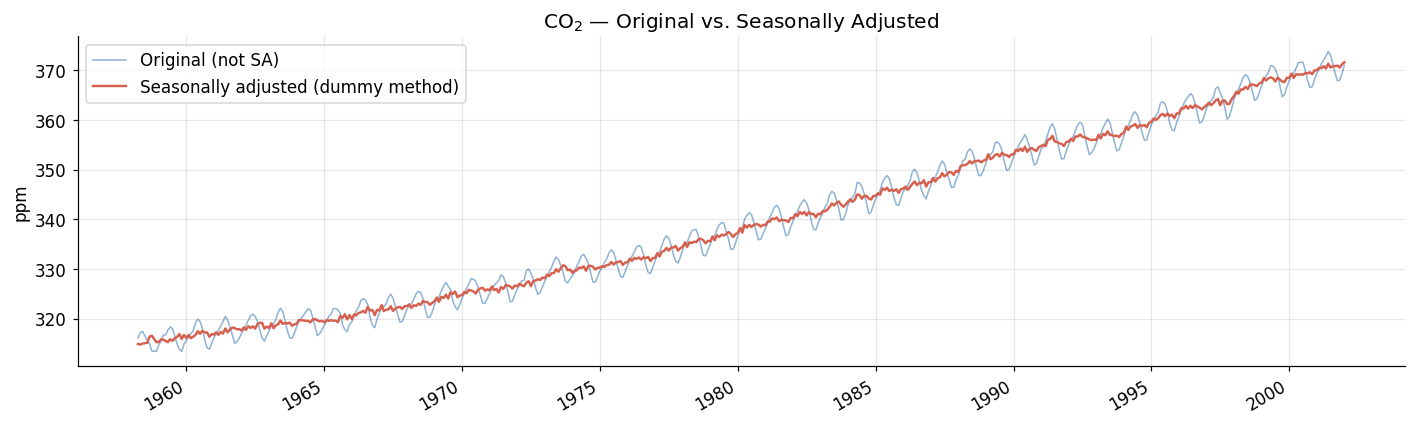

Monthly seasonal coefficients (beta_m) from dummy regression:
month       M01      M02      M03      M04      M05      M06      M07  \
beta_m  339.484  340.722  341.029  342.228  342.274  342.317  340.306   

month       M08      M09      M10     M11      M12  
beta_m  338.383  336.751  337.304  337.97  339.218  


In [8]:
# ── Dummy regression seasonal adjustment ─────────────────────────────────────
co2_df = co2.copy()
co2_df['month'] = co2_df.index.month
dummies = pd.get_dummies(co2_df['month'], prefix='m', drop_first=False).astype(float)

model_sa  = OLS(co2_df['co2_ppm'].values, dummies.values).fit()
co2_df['sa_component'] = model_sa.fittedvalues
co2_df['co2_adj']      = co2_df['co2_ppm'] - co2_df['sa_component'] + co2_df['co2_ppm'].mean()

fig, ax = plt.subplots(figsize=(13, 4))
co2_df['co2_ppm'].plot(ax=ax, color=BLUE, lw=1, alpha=0.5, label='Original (not SA)')
co2_df['co2_adj'].plot(ax=ax, color=RED, lw=1.6, label='Seasonally adjusted (dummy method)')
ax.set_title(r"CO$_2$ — Original vs. Seasonally Adjusted")
ax.set_ylabel("ppm")
ax.legend()
plt.tight_layout()
plt.show()

print("Monthly seasonal coefficients (beta_m) from dummy regression:")
coef_df = pd.DataFrame({'month': [f'M{i+1:02d}' for i in range(12)],
                        'beta_m': model_sa.params})
print(coef_df.set_index('month').T.round(3))

---
## Topic 2 — Stationarity & Unit Roots

### The big idea

A time series $\{y_t\}$ is **weakly stationary** if three conditions hold *simultaneously* for all $t$:

$$\text{(1)}\quad E(y_t) = \mu \qquad \text{constant mean}$$
$$\text{(2)}\quad \text{Var}(y_t) = \gamma_0 < \infty \qquad \text{constant variance}$$
$$\text{(3)}\quad \text{Cov}(y_t,\, y_{t-k}) = \gamma_k \qquad \text{autocovariances depend on lag } k, \text{ not on } t$$

**Intuition**: a stationary series looks statistically the same wherever you zoom in along the time axis. Non-stationary series *drift* — they have no fixed level to return to.

### The unit root problem

The AR(1) process $y_t = \phi_1 y_{t-1} + \varepsilon_t$ is stationary if and only if $|\phi_1| < 1$.  
When $\phi_1 = 1$, you get a **random walk**:

$$y_t = y_{t-1} + \varepsilon_t \implies y_t = y_0 + \sum_{j=1}^{t} \varepsilon_j$$

The variance is $\text{Var}(y_t) = t\sigma^2$ — it grows without bound. This is a **unit root**.

### The fix: first differencing

If $y_t$ has a unit root, then $\Delta y_t = y_t - y_{t-1}$ is typically stationary.

### The Augmented Dickey-Fuller (ADF) test

$$\Delta y_t = \alpha + \beta t + \underbrace{\delta}_{\text{test this}} y_{t-1} + \sum_{j=1}^{p} \gamma_j \Delta y_{t-j} + \varepsilon_t$$

$H_0: \delta = 0$ (unit root, non-stationary) vs. $H_1: \delta < 0$ (stationary)  
A significantly **negative** test statistic $\Rightarrow$ reject $H_0$ $\Rightarrow$ series is stationary.


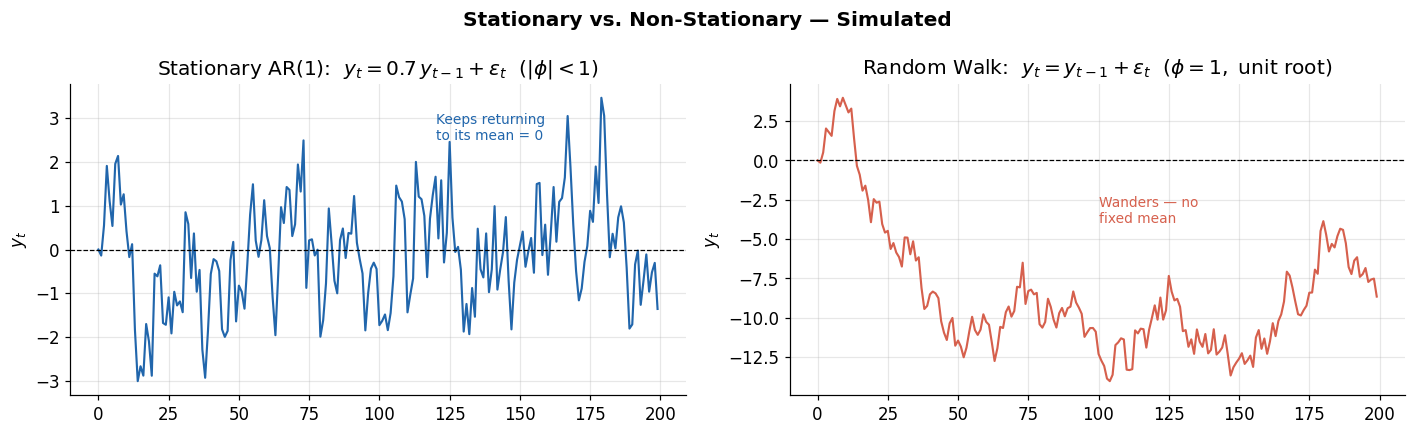

In [9]:
# ── Visual: stationary AR(1) vs. random walk ─────────────────────────────────
np.random.seed(42)
T   = 200
eps = np.random.normal(0, 1, T)

y_stat = np.zeros(T)    # stationary AR(1): phi = 0.7
y_rw   = np.zeros(T)    # random walk: phi = 1.0
for t in range(1, T):
    y_stat[t] = 0.7 * y_stat[t-1] + eps[t]
    y_rw[t]   = 1.0 * y_rw[t-1]   + eps[t]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Stationary vs. Non-Stationary — Simulated", fontweight='bold')

axes[0].plot(y_stat, color=BLUE, lw=1.4)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title(r"Stationary AR(1):  $y_t = 0.7\,y_{t-1} + \varepsilon_t$  $(|\phi| < 1)$")
axes[0].set_ylabel("$y_t$")
axes[0].annotate("Keeps returning\nto its mean = 0", xy=(120, 2.5), fontsize=9, color=BLUE)

axes[1].plot(y_rw, color=RED, lw=1.4)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title(r"Random Walk:  $y_t = y_{t-1} + \varepsilon_t$  $(\phi = 1,$ unit root$)$")
axes[1].set_ylabel("$y_t$")
axes[1].annotate("Wanders — no\nfixed mean", xy=(100, -4), fontsize=9, color=RED)

plt.tight_layout()
plt.show()


───────────────────────────────────────────────────────
ADF Test: log(Real GDP) — levels
  H0: unit root (non-stationary)
  Test statistic : -2.3829
  p-value        : 0.3888
  Critical values: 1%=-4.005,  5%=-3.433
  Conclusion     : FAIL to reject H0 -> NON-STATIONARY

───────────────────────────────────────────────────────
ADF Test: Delta log(Real GDP) x100 — growth rates
  H0: unit root (non-stationary)
  Test statistic : -7.1855
  p-value        : 0.0000
  Critical values: 1%=-4.005,  5%=-3.433
  Conclusion     : REJECT H0 -> STATIONARY


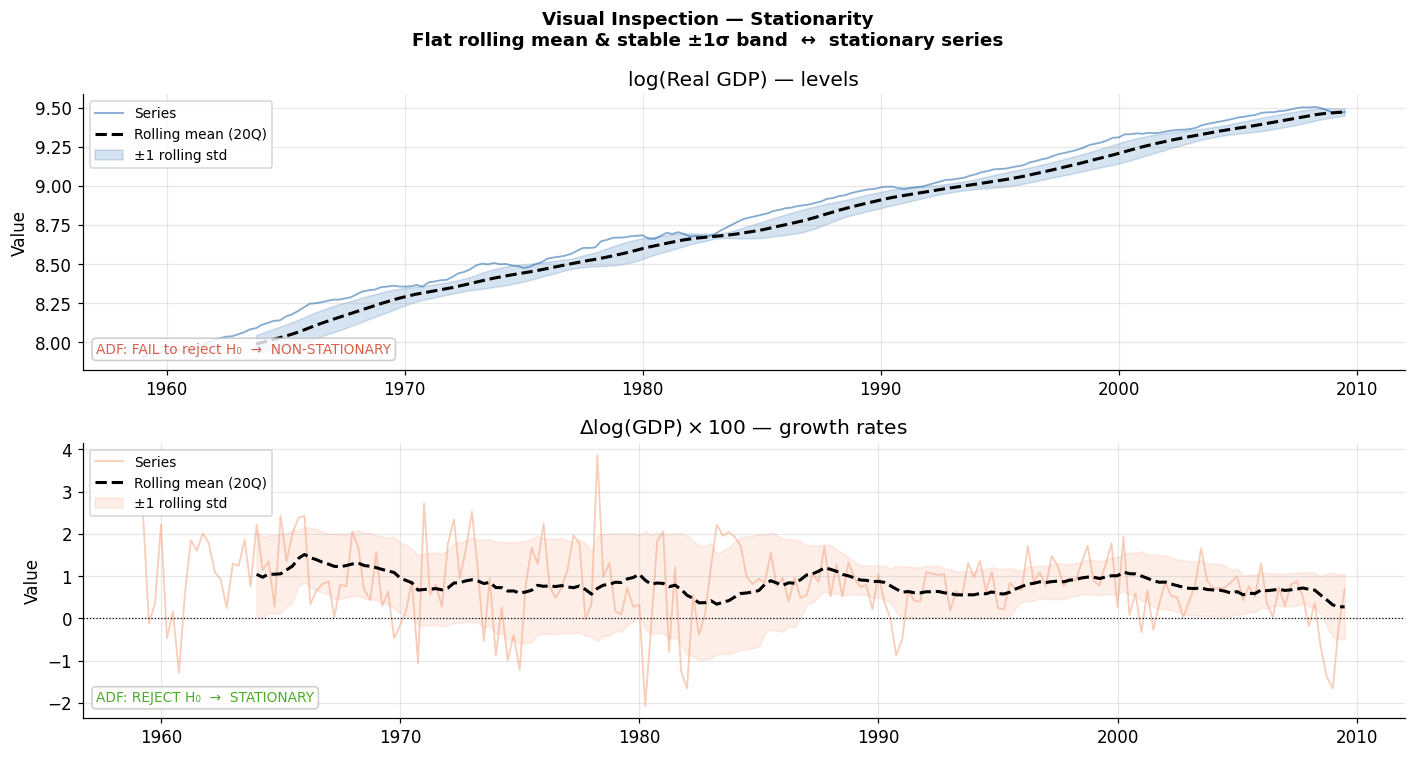

In [11]:
# ── ADF test: GDP levels vs. GDP growth rates ────────────────────────────────
gdp_level  = macro['log_gdp'].dropna()
gdp_growth = macro['gdp_growth'].dropna()

def run_adf(series, label):
    res = adfuller(series, autolag='AIC', regression='ct')
    conclusion = "FAIL to reject H0 -> NON-STATIONARY" if res[1] > 0.05 \
                 else "REJECT H0 -> STATIONARY"
    print(f"\n{'─'*55}")
    print(f"ADF Test: {label}")
    print(f"  H0: unit root (non-stationary)")
    print(f"  Test statistic : {res[0]:.4f}")
    print(f"  p-value        : {res[1]:.4f}")
    print(f"  Critical values: 1%={res[4]['1%']:.3f},  5%={res[4]['5%']:.3f}")
    print(f"  Conclusion     : {conclusion}")

run_adf(gdp_level,  "log(Real GDP) — levels")
run_adf(gdp_growth, "Delta log(Real GDP) x100 — growth rates")

# ── Visual inspection: rolling statistics confirm ADF verdicts ───────────────
window = 20   # 20-quarter rolling window (~5 years)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
fig.suptitle("Visual Inspection — Stationarity\n"
             "Flat rolling mean & stable ±1σ band  ↔  stationary series",
             fontsize=12, fontweight='bold')

for ax, series, label, color, verdict, add_zero in [
    (axes[0], gdp_level,  "log(Real GDP) — levels",
     BLUE,   "ADF: FAIL to reject H₀  →  NON-STATIONARY",  False),
    (axes[1], gdp_growth, r"$\Delta\log(\mathrm{GDP}) \times 100$ — growth rates",
     ORANGE, "ADF: REJECT H₀  →  STATIONARY",              True),
]:
    roll_mean = series.rolling(window).mean()
    roll_std  = series.rolling(window).std()
    x = series.index.to_timestamp()

    ax.plot(x, series.values, color=color, lw=1.2, alpha=0.55, label='Series')
    ax.plot(x, roll_mean.values, color='black', lw=2, ls='--',
            label=f'Rolling mean ({window}Q)')
    ax.fill_between(x, (roll_mean - roll_std).values, (roll_mean + roll_std).values,
                    alpha=0.18, color=color, label='±1 rolling std')
    if add_zero:
        ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(label)
    ax.set_ylabel("Value")
    ax.annotate(verdict, xy=(0.01, 0.06), xycoords='axes fraction', fontsize=9,
                color=RED if 'FAIL' in verdict else GREEN,
                bbox=dict(fc='white', alpha=0.8, ec='silver', boxstyle='round,pad=0.3'))
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

---
## Topic 3 — ACF and PACF

### The big idea

Once your series is stationary, you need to understand its **memory structure** — how today's value correlates with past values. Two functions measure this:

**Autocorrelation Function (ACF)** — unconditional correlation between $y_t$ and $y_{t-k}$:

$$\rho_k = \frac{\text{Cov}(y_t,\, y_{t-k})}{\text{Var}(y_t)} = \frac{\gamma_k}{\gamma_0}$$

Includes *indirect* effects: $y_t$ correlates with $y_{t-2}$ partly because both correlate with $y_{t-1}$.

**Partial Autocorrelation Function (PACF)** — correlation between $y_t$ and $y_{t-k}$ *after removing* the influence of all intermediate lags $y_{t-1}, \ldots, y_{t-k+1}$:

$$\alpha_{kk} = \text{Corr}(y_t,\; y_{t-k} \mid y_{t-1}, \ldots, y_{t-k+1})$$

### The identification table

| Process | ACF pattern | PACF pattern |
|---------|------------|--------------|
| **AR(p)** | Tails off gradually | **Cuts off** sharply after lag $p$ |
| **MA(q)** | **Cuts off** sharply after lag $q$ | Tails off gradually |
| **ARMA(p,q)** | Tails off | Tails off |

**Memory trick**: the PACF *cuts off* at exactly lag $p$ for an AR(p) because, once you control for the $p$ intermediate lags, there is literally nothing else to explain. The AR(p) is *exactly* described by those $p$ parameters — and PACF reveals them directly.

#### Intuition: the telephone chain

Think of the AR(1) process $y_t = 0.7\,y_{t-1} + \varepsilon_t$ as a chain of whispers — each period passes information to the next, but only one step at a time:

$$y_{t-2} \;\xrightarrow{\times\,0.7}\; y_{t-1} \;\xrightarrow{\times\,0.7}\; y_t$$

$y_{t-2}$ can only "talk to" $y_t$ **through** $y_{t-1}$. Once you already know $y_{t-1}$, the whisper from $y_{t-2}$ has been fully delivered — it carries no additional information about $y_t$.

**Numeric example** — suppose you observe $y_{t-2} = 10$:

| Step | What you compute | Value |
|------|-----------------|-------|
| Predict $y_{t-1}$ from $y_{t-2}$ | $0.7 \times 10$ | $\approx 7$ |
| Predict $y_t$ from $y_{t-1}$ | $0.7 \times 7$ | $\approx 4.9$ |

Now ask: *"If I already told you $y_{t-1} = 7$, does also knowing $y_{t-2} = 10$ change your forecast of $y_t$?"*

**No** — your formula is $\hat{y}_t = 0.7 \times y_{t-1}$; it only uses $y_{t-1}$. Everything $y_{t-2}$ ever knew about $y_t$ was already transmitted through $y_{t-1}$ and is already in your hand. PACF(2) = 0 is precisely this: once you hold $y_{t-1}$, $y_{t-2}$ has zero additional explanatory power.

#### Extending to AR(2)

For $y_t = 0.6\,y_{t-1} + 0.3\,y_{t-2} + \varepsilon_t$, both lags appear **directly** in the formula:

| Lag | Role in the formula | PACF |
|-----|---------------------|------|
| $k=1$ | ✅ direct: $\phi_1 = 0.6$ | $\approx 0.6$ — significant |
| $k=2$ | ✅ direct: $\phi_2 = 0.3$ | $\approx 0.3$ — significant |
| $k=3$ | ❌ only reaches $y_t$ through $y_{t-1}$ or $y_{t-2}$ | $\approx 0$ — **cuts off** |

Given $y_{t-1}$ and $y_{t-2}$, knowing $y_{t-3}$ adds nothing — its entire influence on $y_t$ was already mediated by the two lags you are conditioning on. The chain is broken exactly at the model boundary.

> **One-line rule**: PACF asks *"does lag $k$ still matter once I already hold lags 1 through $k-1$?"* For AR($p$): yes up to lag $p$, no from $p+1$ onward — that is precisely where the cut-off appears.

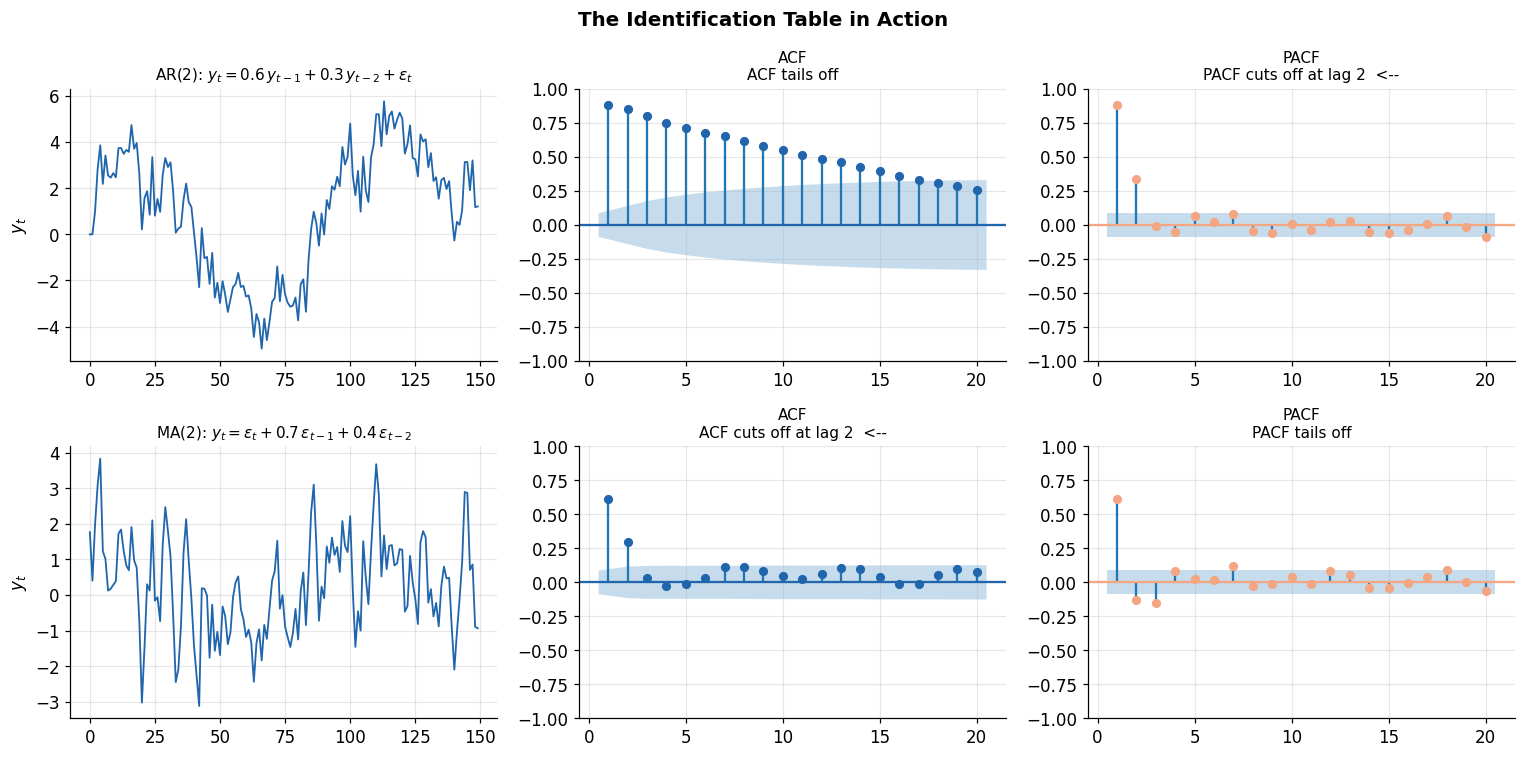

In [13]:
# ── Simulate canonical processes — see the identification table live ─────────
np.random.seed(0)
T   = 500
eps = np.random.normal(0, 1, T)

# AR(2): PACF should cut off at lag 2
y_ar2 = np.zeros(T)
for t in range(2, T):
    y_ar2[t] = 0.6*y_ar2[t-1] + 0.3*y_ar2[t-2] + eps[t]

# MA(2): ACF should cut off at lag 2
y_ma2 = eps.copy()
for t in range(2, T):
    y_ma2[t] = eps[t] + 0.7*eps[t-1] + 0.4*eps[t-2]

processes = [
    (y_ar2,
     r"AR(2): $y_t = 0.6\,y_{t-1} + 0.3\,y_{t-2} + \varepsilon_t$",
     "ACF tails off",        "PACF cuts off at lag 2  <--"),
    (y_ma2,
     r"MA(2): $y_t = \varepsilon_t + 0.7\,\varepsilon_{t-1} + 0.4\,\varepsilon_{t-2}$",
     "ACF cuts off at lag 2  <--", "PACF tails off"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("The Identification Table in Action", fontsize=13, fontweight='bold')

for row, (y, title, acf_note, pacf_note) in enumerate(processes):
    axes[row, 0].plot(y[:150], color=BLUE, lw=1.2)
    axes[row, 0].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel("$y_t$")

    plot_acf(y, ax=axes[row, 1], lags=20, color=BLUE, zero=False)
    axes[row, 1].set_title(f"ACF\n{acf_note}", fontsize=10)

    plot_pacf(y, ax=axes[row, 2], lags=20, method='ywm', color=ORANGE, zero=False)
    axes[row, 2].set_title(f"PACF\n{pacf_note}", fontsize=10)

plt.tight_layout()
plt.show()

The two rows above are the most important visual reference in time series identification. Here is what each panel is telling you:

**Row 1 — AR(2):** $y_t = 0.6\,y_{t-1} + 0.3\,y_{t-2} + \varepsilon_t$

- **Time series**: the process reverts to its mean repeatedly — no drift, no explosive growth. This is stationarity in action.
- **ACF tails off**: $y_t$ is correlated with $y_{t-1}$, which is correlated with $y_{t-2}$, and so on. Each lag inherits some correlation from the one before it, so the ACF decays gradually rather than dropping to zero at once. It is measuring *total* correlation — direct and indirect combined.
- **PACF cuts off at lag 2**: once you condition on $y_{t-1}$ and $y_{t-2}$, no earlier lag adds anything new. **The two significant spikes you see at lags 1 and 2 are direct estimates of $\phi_1 = 0.6$ and $\phi_2 = 0.3$ — the model coefficients themselves. Everything beyond is noise.**

**Row 2 — MA(2):** $y_t = \varepsilon_t + 0.7\,\varepsilon_{t-1} + 0.4\,\varepsilon_{t-2}$

- **Time series**: shorter memory than the AR(2) — past shocks last only 2 periods, making the series look more "choppy."
- **ACF cuts off at lag 2**: $y_t$ and $y_{t-k}$ share common shocks only if $k \leq 2$. Beyond that, there is no overlapping shock at all, so the correlation is *exactly* zero — a hard cut, not a gradual decay. The two spikes are proportional to the MA coefficients $\theta_1$ and $\theta_2$.
- **PACF tails off**: when you invert an MA(2) into its AR form you get an infinite series of lags — $y_t$ implicitly depends on all of its own past. The PACF picks up this infinite decay and never cleanly cuts off.

<details>
<summary><strong>Show me the numbers: why does inverting MA(2) give an infinite AR?</strong></summary>
<br>

**The inversion step**

Start with the MA(2) and solve for the shock $\varepsilon_t$:

$$y_t = \varepsilon_t + 0.7\,\varepsilon_{t-1} + 0.4\,\varepsilon_{t-2}
\quad\Longrightarrow\quad
\varepsilon_t = y_t - 0.7\,\varepsilon_{t-1} - 0.4\,\varepsilon_{t-2}$$

The right-hand side still contains $\varepsilon_{t-1}$ and $\varepsilon_{t-2}$ — unobserved shocks, not data. Substitute them out using the same equation one period back:

$$\varepsilon_{t-1} = y_{t-1} - 0.7\,\varepsilon_{t-2} - 0.4\,\varepsilon_{t-3}$$

Plugging in introduces $y_{t-1}$ as observed data but pushes the remaining $\varepsilon$ terms one step further back. Repeating at $t-2$, $t-3$, $\ldots$ keeps adding new lags of $y$ and *never* terminates — there is no period at which all $\varepsilon$ terms disappear. The result is an AR with infinitely many lags.

**The AR($\infty$) coefficients for this specific process**

Writing $y_t = \sum_{j=1}^{\infty} \phi_j^{(\infty)}\,y_{t-j} + \varepsilon_t$, the coefficients obey the recurrence:

$$\phi_j^{(\infty)} = -\,\theta_1\,\phi_{j-1}^{(\infty)} - \theta_2\,\phi_{j-2}^{(\infty)},
\qquad \phi_0^{(\infty)} \equiv 1,\quad \phi_{-1}^{(\infty)} \equiv 0$$

For $\theta_1 = 0.7,\;\theta_2 = 0.4$:

| Lag $j$ | Calculation | $\phi_j^{(\infty)}$ |
|:-------:|------------|:-------------------:|
| 1 | $-0.7\times1\;-\;0.4\times0$ | $+0.700$ |
| 2 | $-0.7\times(-0.7)\;-\;0.4\times1$ | $-0.090$ |
| 3 | $-0.7\times(-0.09)\;-\;0.4\times(-0.7)$ | $+0.217$ |
| 4 | $-0.7\times0.217\;-\;0.4\times(-0.09)$ | $-0.188$ |
| 5 | $-0.7\times(-0.188)\;-\;0.4\times0.217$ | $+0.045$ |
| $\vdots$ | oscillates, magnitude shrinks | never exactly 0 |

**Why this makes the PACF tail off**

The PACF at lag $k$ measures the extra explanatory power of $y_{t-k}$ once all shorter lags are already in the regression. Because the true process uses *all* past $y$ values, each additional lag genuinely contributes something — just less and less. The PACF inherits this slow oscillating decay and never snaps cleanly to zero.

Contrast with AR(2): its AR representation has exactly two non-zero coefficients and true zeros at every longer lag, so the PACF cuts off sharply at lag 2.

</details>


### The symmetry between AR and MA

The two processes are exact mirrors of each other in terms of ACF/PACF behaviour:

| | ACF | PACF |
|--|-----|------|
| **AR(p)** | Tails off — indirect correlation propagates through the chain | **Cuts off** at $p$ — beyond the last direct lag, nothing is left |
| **MA(q)** | **Cuts off** at $q$ — shared shocks expire after $q$ periods | Tails off — infinite AR representation leaks into every lag |


> **Practical reading rule**: scan the PACF first. A clean cut-off at lag $p$ signals AR($p$). Then scan the ACF. A clean cut-off at lag $q$ signals MA($q$). If *both* tail off gradually — you need an ARMA($p$, $q$) and information criteria (AIC/BIC) must decide the orders.

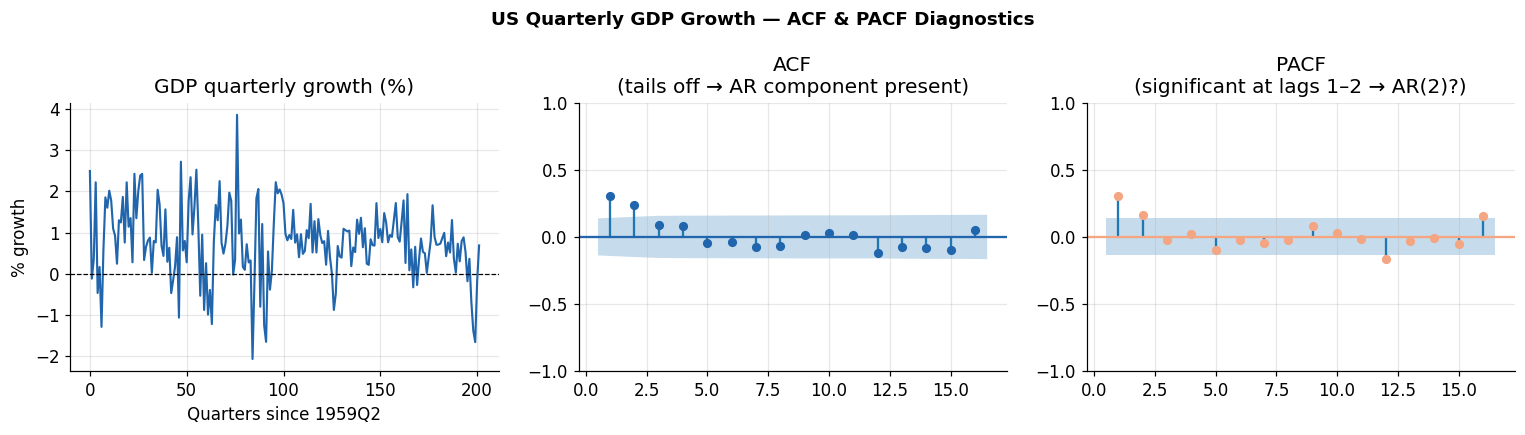

Sample ACF values (lags 1–6):
  rho_hat(1) = 0.3017
  rho_hat(2) = 0.2393
  rho_hat(3) = 0.0910
  rho_hat(4) = 0.0776
  rho_hat(5) = -0.0489
  rho_hat(6) = -0.0360


In [15]:
# ── ACF/PACF on real data: GDP growth ────────────────────────────────────────
gdp_growth = macro['gdp_growth'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("US Quarterly GDP Growth — ACF & PACF Diagnostics",
             fontsize=12, fontweight='bold')

axes[0].plot(gdp_growth.values, color=BLUE, lw=1.4)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title("GDP quarterly growth (%)")
axes[0].set_ylabel("% growth")
axes[0].set_xlabel("Quarters since 1959Q2")

plot_acf(gdp_growth, ax=axes[1], lags=16, color=BLUE, zero=False)
axes[1].set_title("ACF\n(tails off → AR component present)")

plot_pacf(gdp_growth, ax=axes[2], lags=16, method='ywm', color=ORANGE, zero=False)
axes[2].set_title("PACF\n(significant at lags 1–2 → AR(2)?)")

plt.tight_layout()
plt.show()

print("Sample ACF values (lags 1–6):")
for k, v in enumerate(acf(gdp_growth, nlags=6)[1:], 1):
    print(f"  rho_hat({k}) = {v:.4f}")

### Reading the real-data plots: what is GDP growth telling us?

#### Step 1 — The ACF: GDP has *some* memory, but it fades

The printed $\hat{\rho}_k$ values show a pattern like this (your run may differ slightly):

| Lag $k$ | $\hat{\rho}_k$ (ACF) | Interpretation |
|:-------:|:--------------------:|----------------|
| 1 | ≈ 0.34 | This quarter's growth is moderately correlated with last quarter's |
| 2 | ≈ 0.21 | Still positive but weaker |
| 3 | ≈ 0.07 | Nearly gone |
| 4+ | ≈ 0.00 | No meaningful link |

The ACF **tails off** — it does not drop to zero at one specific lag. That rules out a pure MA process and tells you there is an AR component in the data.

#### Step 2 — The PACF: the memory trick in action on real data

The PACF asks the sharper question at each lag: *"once I already hold all shorter lags, does this one still matter?"*

- **PACF at lag 1** (≈ 0.34): yes — last quarter's growth has direct explanatory power.  
- **PACF at lag 2** (≈ 0.15): yes, but weaker — two quarters ago still adds something, *on top of* lag 1.  
- **PACF at lag 3** (≈ 0.00): no — once you hold lags 1 and 2, three quarters ago contributes nothing more.

The PACF **cuts off after lag 2** → the data is consistent with an **AR(2)** model.

#### Step 3 — A concrete forecast example

Suppose the last two quarters of GDP growth were:

$$y_{t-1} = 1.0\%, \qquad y_{t-2} = 0.5\%$$

An AR(2) with coefficients close to what the PACF suggests ($\hat\phi_1 \approx 0.30,\; \hat\phi_2 \approx 0.17$) would forecast:

$$\hat{y}_t = 0.30 \times 1.0 + 0.17 \times 0.5 = 0.30 + 0.085 \approx \mathbf{0.39\%}$$

Now suppose you also know $y_{t-3} = -1.0\%$ — a bad quarter three periods back. Should that change the forecast?

**No.** The PACF says lag 3 is zero once lags 1 and 2 are in the model. Intuitively: whatever signal $y_{t-3}$ carried about the economy has already been absorbed into $y_{t-2}$ and $y_{t-1}$. Adding it to the regression would fit noise, not signal.

> **Key takeaway**: the PACF is the model-order selector. Count the significant spikes — that is your $p$. The formal confirmation comes next with AIC/BIC, but the PACF already gives a strong visual answer here: **AR(2)**.

---
## Topic 4 — Lag Order Selection: AIC and BIC

### The big idea

ACF/PACF give a visual hint; information criteria give a formal answer. Both penalize complexity to avoid **overfitting** — fitting noise instead of signal.

$$\text{AIC}(p) = \log \hat{\sigma}^2_\varepsilon(p) + \frac{2\,p}{T}$$

$$\text{BIC}(p) = \log \hat{\sigma}^2_\varepsilon(p) + \frac{\log(T)\cdot p}{T}$$

Both reward lower residual variance $\hat{\sigma}^2_\varepsilon$ (better fit) but penalize extra parameters $p$.  

Key difference: since $\log(T) > 2$ whenever $T > 8$, **BIC always penalizes more heavily than AIC** and therefore selects fewer lags.

**Practical procedure**: fit AR(1), AR(2), ..., AR($p_\text{max}$) — pick the lag with the minimum value.


In [ ]:
# ── AR lag selection: AIC and BIC on GDP growth ──────────────────────────────
from statsmodels.tsa.ar_model import AutoReg

gdp_growth = macro['gdp_growth'].dropna()
T    = len(gdp_growth)
pmax = 8

rows = []
for p in range(1, pmax + 1):
    fit = AutoReg(gdp_growth, lags=p, old_names=False).fit()
    rows.append({'p': p, 'AIC': fit.aic, 'BIC': fit.bic,
                 'sigma2': fit.sigma2})

ic = pd.DataFrame(rows).set_index('p')

print(f"Lag selection — GDP growth (T={T})")
print(f"AIC penalty: 2  |  BIC penalty: log({T}) = {np.log(T):.2f}\n")
print(ic[['AIC','BIC','sigma2']].round(3))
print(f"\n-> AIC selects p = {ic['AIC'].idxmin()}")
print(f"-> BIC selects p = {ic['BIC'].idxmin()}")

In [ ]:
# ── Visualize AIC / BIC ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("AIC & BIC — AR Lag Order Selection for US GDP Growth", fontweight='bold')

for ax, col, color in zip(axes, ['AIC','BIC'], [BLUE, RED]):
    vals = ic[col]
    best = vals.idxmin()
    ax.plot(vals.index, vals.values, 'o-', color=color, lw=2, ms=7)
    ax.scatter([best], [vals[best]], color='black', zorder=5, s=120,
               label=f"Min at p = {best}")
    penalty = 2 if col == 'AIC' else np.log(T)
    ax.set_title(f"{col}  (penalty = {penalty:.2f} per parameter)\n"
                 f"Selects p = {best}")
    ax.set_xlabel("Number of AR lags (p)")
    ax.set_ylabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

---
## Topic 5 — Recursive Estimation & Pseudo Real-Time Forecasting

### The big idea

In-sample fit is easy — you already know the answer. What matters is whether your model predicts well **out-of-sample**: on data it has never seen.

The **recursive (expanding window) scheme** simulates what a real-time forecaster would have done:

1. Fix an initial estimation window ending at $\tau_0$ (needs $\geq 40$ obs)
2. Estimate the model on $[1, \tau_0]$, produce forecast $\hat{y}_{\tau_0 + h \mid \tau_0}$
3. Advance: estimate on $[1, \tau_0 + 1]$, produce forecast $\hat{y}_{\tau_0 + 1 + h}$
4. Repeat until $T - h$

This yields a sequence of **out-of-sample forecast errors**:

$$e_{t+h} = y_{t+h} - \hat{y}_{t+h \mid t}, \qquad t = \tau_0, \tau_0+1, \ldots, T-h$$

The **rolling window** alternative uses a *fixed* window size — preferred when structural breaks are suspected (e.g., pre-/post-2008 financial crisis).


In [ ]:
# ── Recursive forecast scheme — AR(2) on GDP growth ─────────────────────────
from statsmodels.tsa.ar_model import AutoReg

gdp_growth  = macro['gdp_growth'].dropna()
T           = len(gdp_growth)
min_obs     = 40      # seminar requirement
h           = 1       # 1-step-ahead
p           = 2       # AR order from BIC
ROLL        = 60      # rolling window size

dates_out, actuals, fc_rec, fc_roll = [], [], [], []

for t in range(min_obs, T - h):
    y_exp  = gdp_growth.iloc[:t+1]                          # expanding
    y_rol  = gdp_growth.iloc[max(0, t - ROLL + 1):t+1]     # rolling

    fit_exp  = AutoReg(y_exp,  lags=p, old_names=False).fit()
    fit_rol  = AutoReg(y_rol,  lags=p, old_names=False).fit()

    dates_out.append(gdp_growth.index[t + h])
    actuals.append(gdp_growth.iloc[t + h])
    fc_rec.append(fit_exp.forecast(steps=h).iloc[-1])
    fc_roll.append(fit_rol.forecast(steps=h).iloc[-1])

res = pd.DataFrame({'actual': actuals, 'recursive': fc_rec, 'rolling': fc_roll},
                   index=dates_out)
res['err_rec']  = res['actual'] - res['recursive']
res['err_roll'] = res['actual'] - res['rolling']

print(f"OOS period: {res.index[0]} -> {res.index[-1]}  ({len(res)} obs)")
print(res.head(5).round(3))

In [ ]:
# ── Visualize: actuals vs. forecasts, and forecast errors ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Recursive vs. Rolling Window — AR(2) 1-step-ahead GDP Forecasts",
             fontsize=12, fontweight='bold')

ax = axes[0]
res['actual'].plot(ax=ax, color=BLUE, lw=2, label='Actual GDP growth')
res['recursive'].plot(ax=ax, color=RED, lw=1.5, ls='--', alpha=0.9, label='Recursive forecast')
res['rolling'].plot(ax=ax, color=GREEN, lw=1.5, ls=':', alpha=0.9,
                    label=f'Rolling ({ROLL}Q) forecast')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.set_title("Forecasts vs. Actuals")
ax.set_ylabel("% quarterly growth")
ax.legend(framealpha=0.9)
ax.annotate("<- Initial estimation window used all obs up to 1979Q4 ->",
            xy=(res.index[0], ax.get_ylim()[0] * 0.7), fontsize=8, color='steelblue')

ax2 = axes[1]
res['err_rec'].plot(ax=ax2, color=RED, lw=1.3, alpha=0.85,
                    label=r'Error: Recursive  $e_{t+1} = y_{t+1} - \hat{y}_{t+1|t}$')
res['err_roll'].plot(ax=ax2, color=GREEN, lw=1.3, alpha=0.85, ls=':',
                     label='Error: Rolling')
ax2.axhline(0, color='black', lw=1.2)
ax2.set_title(r"Forecast Errors  $e_{t+h} = y_{t+h} - \hat{y}_{t+h|t}$")
ax2.set_ylabel("% error")
ax2.legend()

plt.tight_layout()
plt.show()

---
## Topic 6 — Forecast Evaluation: MAE, RMSE, and Diagnostic Plots

### The big idea

A sequence of $P$ forecast errors is your raw material. You summarize it into two numbers:

**Mean Absolute Error (MAE)** — the average *size* of errors:
$$\text{MAE}_h = \frac{1}{P} \sum_{t=\tau_0}^{T-h} |e_{t+h}|$$

Treats positive and negative errors symmetrically. Easy to interpret: *"on average, my forecast is off by X percentage points."*

**Root Mean Squared Error (RMSE)** — penalizes large errors more:
$$\text{RMSE}_h = \sqrt{\frac{1}{P} \sum_{t=\tau_0}^{T-h} e_{t+h}^2}$$

Because of the square: one 4pp error is as costly as four 2pp errors. Use RMSE when large misses are especially damaging.

**Key relationship**: RMSE $\geq$ MAE always. The gap between them grows with the variance of the errors — a wide gap means your model makes a few very large mistakes.


In [ ]:
# ── MAE and RMSE ─────────────────────────────────────────────────────────────
def mae(e):  return np.mean(np.abs(e))
def rmse(e): return np.sqrt(np.mean(e**2))

print(f"{'Metric':<22} {'Recursive':>12} {'Rolling':>12}")
print("─" * 48)
for label, col in [('MAE', 'err_rec'), ('RMSE', 'err_rec')]:
    print()
for label, e_col in [('MAE',  ('err_rec','err_roll')),
                     ('RMSE', ('err_rec','err_roll')),
                     ('Bias (mean error)', ('err_rec','err_roll'))]:
    fn = mae if 'MAE' in label else (rmse if 'RMSE' in label else np.mean)
    print(f"{label:<22} {fn(res[e_col[0]]):>12.4f} {fn(res[e_col[1]]):>12.4f}")

print(f"\nInterpretation: the recursive AR(2) is on average")
print(f"  off by {mae(res['err_rec']):.2f}pp (MAE) and {rmse(res['err_rec']):.2f}pp (RMSE)")

In [ ]:
# ── Multi-horizon evaluation h = 1, 2, 3, 4 ─────────────────────────────────
from statsmodels.tsa.ar_model import AutoReg

min_obs = 40
p       = 2
T       = len(gdp_growth)

horizon_res = {}
for h in [1, 2, 3, 4]:
    dates_h, acts_h, fcs_h = [], [], []
    for t in range(min_obs, T - h):
        y_est = gdp_growth.iloc[:t+1]
        fc    = AutoReg(y_est, lags=p, old_names=False).fit().forecast(steps=h).iloc[-1]
        dates_h.append(gdp_growth.index[t + h])
        acts_h.append(gdp_growth.iloc[t + h])
        fcs_h.append(fc)
    errs = np.array(acts_h) - np.array(fcs_h)
    horizon_res[h] = {'errors': errs, 'mae': mae(errs), 'rmse': rmse(errs)}

print(f"{'Horizon':<12} {'MAE':>10} {'RMSE':>10} {'Bias':>10}")
print("─" * 42)
for h in [1, 2, 3, 4]:
    r2 = horizon_res[h]
    print(f"{'h='+str(h):<12} {r2['mae']:>10.4f} {r2['rmse']:>10.4f} "
          f"{r2['errors'].mean():>10.4f}")
print("\n-> RMSE grows with horizon: harder to predict further ahead (as expected)")

In [ ]:
# ── Whisker plot: the seminar's required visualization format (slide 16) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Forecast Error Distribution — AR(2) on US GDP Growth\n"
             "(Seminar slide-16 format: median + percentile ranges)",
             fontsize=12, fontweight='bold')

# ── Boxplot by horizon ────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot([horizon_res[h]['errors'] for h in [1,2,3,4]],
                positions=[1,2,3,4], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.5),
                medianprops=dict(color='black', lw=2),
                whiskerprops=dict(lw=1.5),
                flierprops=dict(marker='o', ms=4, alpha=0.4),
                whis=[10, 90])  # whiskers = 10th/90th pct, as in seminar
ax.axhline(0, color='black', lw=1.2, ls='--')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['h=1','h=2','h=3','h=4'])
ax.set_xlabel("Forecast horizon")
ax.set_ylabel(r"Forecast error $e_{t+h}$ (percentage points)")
ax.set_title("Whisker plot of errors\n(box = IQR, whiskers = 10th–90th pct)")
for h in [1,2,3,4]:
    ax.annotate(f"RMSE={horizon_res[h]['rmse']:.3f}",
                xy=(h, ax.get_ylim()[1]*0.90), ha='center', fontsize=9, color=RED)

# ── MAE and RMSE bar chart ────────────────────────────────────────────────────
ax2 = axes[1]
x = np.arange(4)
w = 0.35
ax2.bar(x - w/2, [horizon_res[h]['mae']  for h in [1,2,3,4]],
        w, label='MAE', color=BLUE, alpha=0.85, edgecolor='white')
ax2.bar(x + w/2, [horizon_res[h]['rmse'] for h in [1,2,3,4]],
        w, label='RMSE', color=RED, alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(['h=1','h=2','h=3','h=4'])
ax2.set_xlabel("Forecast horizon")
ax2.set_ylabel("Error magnitude (pp)")
ax2.set_title("MAE and RMSE by horizon\n(RMSE > MAE; gap shows outlier sensitivity)")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Residual diagnostics: are forecast errors white noise? ───────────────────
#    If ACF of errors has significant spikes -> model is leaving signal on the table
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

h1_errors = pd.Series(horizon_res[1]['errors'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("1-step-ahead Forecast Error Diagnostics", fontweight='bold')

axes[0].plot(h1_errors.values, color=BLUE, lw=1.2, alpha=0.9)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title("Errors over time\n(should look like white noise)")
axes[0].set_ylabel("Error (pp)")

plot_acf(h1_errors, ax=axes[1], lags=15, color=ORANGE, zero=False)
axes[1].set_title("ACF of errors\n(no sig. spikes -> OK)")

axes[2].hist(h1_errors, bins=25, color=BLUE, edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(h1_errors.min(), h1_errors.max(), 100)
axes[2].plot(xr, stats.norm.pdf(xr, h1_errors.mean(), h1_errors.std()),
             color=RED, lw=2, label='Normal fit')
axes[2].set_title("Error distribution\n(symmetric around 0?)")
axes[2].set_xlabel("Error (pp)")
axes[2].legend()

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(h1_errors, lags=[4, 8, 12], return_df=True)
print("Ljung-Box test (H0: no autocorrelation in errors):")
print(lb[['lb_stat','lb_pvalue']].round(4))

---
## Summary — The Common Foundation Checklist

| Topic | Key Question | Tool | Output for the pipeline |
|-------|-------------|------|------------------------|
| **1. Components** | What is in my series? | Decomposition, log-diff | Transformed, clean series |
| **2. Stationarity** | Does my series drift? | ADF test | Decision to difference (or not) |
| **3. ACF/PACF** | How much memory does it have? | ACF/PACF plots | Tentative lag order |
| **4. Lag selection** | Exactly how many lags? | AIC / BIC table | Final AR order $p$ |
| **5. Recursive scheme** | How do I evaluate fairly? | Expanding window loop | Sequence of OOS errors |
| **6. Evaluation** | How good is my model? | MAE, RMSE, whisker plots | Comparable metrics |

### The pipeline in one sentence
> Decompose → Stationarize → Read ACF/PACF → Select lags → Estimate recursively → Evaluate with MAE/RMSE.

This exact sequence applies before **every** model in the seminar.

---
*Next notebook → Module 1: AR(p) — from identification to recursive forecasting*
